In [17]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_iris
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [18]:
iris = load_iris()

X = iris.data
y = iris.target

feature_names = iris.feature_names
class_names = iris.target_names

print("Dataset Shape :", X.shape)
print("Number of Samples :", len(X))
print("Number of Features :", X.shape[1])

print("\nFeature Names")
print(feature_names)

print("\nClasses")
print(class_names)

Dataset Shape : (150, 4)
Number of Samples : 150
Number of Features : 4

Feature Names
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Classes
['setosa' 'versicolor' 'virginica']


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training Samples :", len(X_train))
print("Testing Samples :", len(X_test))

Training Samples : 105
Testing Samples : 45


In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
# Original training data

X_train_reduced = X_train_scaled.copy()
y_train_reduced = y_train.copy()

print("Original Samples :", len(X_train_scaled))
print("Reduced Samples :", len(X_train_reduced))

Original Samples : 105
Reduced Samples : 105


In [ ]:
# knn = KNeighborsClassifier(
#     n_neighbors=5,
#     metric="euclidean",
#     weights="uniform"
# )

# knn.fit(X_train_reduced, y_train_reduced)
# By default algorithm = brute

knn = KNeighborsClassifier(
    n_neighbors=5,
    metric="euclidean",
    weights="uniform",
    algorithm="kd_tree"
)

knn.fit(X_train_reduced, y_train_reduced)

,n_neighbors,5
,weights,'uniform'
,algorithm,'kd_tree'
,leaf_size,30
,p,2
,metric,'euclidean'
,metric_params,None
,n_jobs,None


In [21]:
y_pred = knn.predict(X_test_scaled)

In [22]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")

Accuracy : 0.9111


In [23]:
precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

Precision : 0.9298
Recall    : 0.9111
F1 Score  : 0.9095


In [24]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[15  0  0]
 [ 0 15  0]
 [ 0  4 11]]


In [14]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.79      1.00      0.88        15
   virginica       1.00      0.73      0.85        15

    accuracy                           0.91        45
   macro avg       0.93      0.91      0.91        45
weighted avg       0.93      0.91      0.91        45



In [15]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    KNeighborsClassifier(
        n_neighbors=5,
        metric="euclidean"
    ),
    scaler.fit_transform(X),
    y,
    cv=cv,
    scoring="accuracy"
)

print("Fold Accuracies")
print(cv_scores)

print("\nMean Accuracy :", np.mean(cv_scores))
print("Standard Deviation :", np.std(cv_scores))

Fold Accuracies
[1.         0.96666667 0.9        1.         0.96666667]

Mean Accuracy : 0.9666666666666666
Standard Deviation : 0.036514837167011066


In [16]:
summary = pd.DataFrame({

    "Metric":[
        "Training Samples",
        "Reduced Samples",
        "Testing Samples",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Value":[
        len(X_train_scaled),
        len(X_train_reduced),
        len(X_test_scaled),
        round(accuracy,4),
        round(precision,4),
        round(recall,4),
        round(f1,4)
    ]
})

summary

,Metric,Value
0,Training Samples,105.0000
1,Reduced Samples,105.0000
2,Testing Samples,45.0000
3,Accuracy,0.9111
4,Precision,0.9298
5,Recall,0.9111
6,F1 Score,0.9095


### LSH

In [25]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.decomposition import PCA

In [26]:
iris = load_iris()

X = iris.data
y = iris.target

# Reduce 4D -> 2D only for visualization
pca = PCA(n_components=2)
X_2D = pca.fit_transform(X)

In [27]:
np.random.seed(42)

num_planes = 5

# Random line directions
planes = np.random.randn(num_planes, 2)

print("Random Hyperplanes:\n")
print(planes)

Random Hyperplanes:

[[ 0.49671415 -0.1382643 ]
 [ 0.64768854  1.52302986]
 [-0.23415337 -0.23413696]
 [ 1.57921282  0.76743473]
 [-0.46947439  0.54256004]]


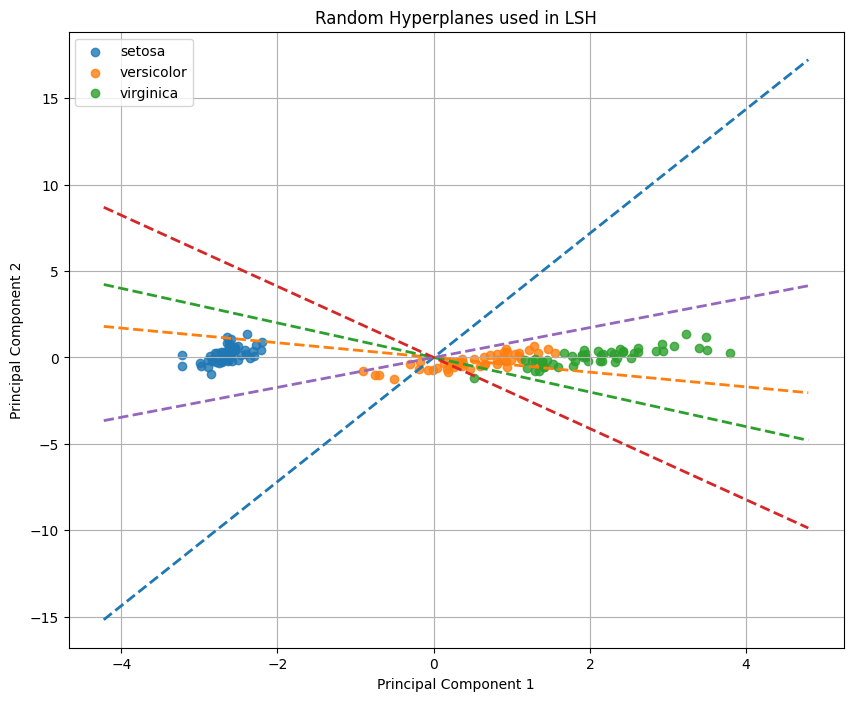

In [28]:
plt.figure(figsize=(10,8))

colors = ['red','green','blue']

# Plot Iris samples
for i, name in enumerate(iris.target_names):
    plt.scatter(
        X_2D[y==i,0],
        X_2D[y==i,1],
        label=name,
        alpha=0.8
    )

# Draw each random hyperplane
x = np.linspace(
    X_2D[:,0].min()-1,
    X_2D[:,0].max()+1,
    300
)

for plane in planes:

    a, b = plane

    # Hyperplane equation:
    # a*x + b*y = 0
    # => y = -(a/b)x

    if abs(b) > 1e-6:

        y_line = -(a/b)*x

        plt.plot(
            x,
            y_line,
            '--',
            linewidth=2
        )

plt.title("Random Hyperplanes used in LSH")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)

plt.show()

In [29]:
hash_codes = []

for point in X_2D:

    code = ""

    for plane in planes:

        # Dot product

        if np.dot(point, plane) >= 0:
            code += "1"
        else:
            code += "0"

    hash_codes.append(code)

print("First 15 Hash Codes\n")

for i in range(15):
    print(hash_codes[i])

First 15 Hash Codes

00101
00101
00101
00101
00101
00101
00101
00101
00101
00101
00101
00101
00101
00101
01101


In [30]:
from collections import defaultdict

buckets = defaultdict(list)

for i, code in enumerate(hash_codes):
    buckets[code].append(i)

print("Buckets\n")

for key, value in buckets.items():
    print(f"{key} ---> {value}")

Buckets

00101 ---> [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 98]
01101 ---> [14, 15]
11010 ---> [50, 51, 52, 54, 56, 58, 61, 63, 65, 70, 71, 72, 73, 74, 75, 76, 77, 78, 83, 85, 86, 91, 97, 100, 101, 102, 103, 104, 105, 107, 108, 109, 110, 111, 112, 114, 115, 116, 117, 118, 120, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149]
10100 ---> [53, 59, 62, 69, 80, 82, 89, 106]
10010 ---> [55, 66, 68, 84, 87, 95, 96, 113, 119, 121]
00100 ---> [57, 60, 64, 79, 81, 93]
10110 ---> [67, 88, 90, 92, 94, 99]


Main steps followed in Locality-Sensitive Hashing (LSH):

Load Training Data

Preprocess / Normalize Features (if required)

Generate Random Hyperplanes

Compute Hash Code for Each Training Sample

Store Samples into Hash Buckets (Hash Tables)

Receive a Test Query

Compute the Query's Hash Code

Retrieve Candidate Neighbors from the Same (or Nearby) Buckets

Compute Exact Distance Only for Candidate Points

Select the k Nearest Neighbors

Apply Majority Voting (KNN Classification)

Return the Predicted Class